# Módulo 6 tarefa 3

#### 1) A base 'sinasc_RO_2019.csv' contém dados do sistema de nascidos vivos do DataSUS, cujo dicionário de dados está no arquivo 'Estrutura_SINASC_para_CD.pdf'. Carregue esse arquivo.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

df_sinasc = pd.read_csv('Profissão Cientista de Dados M6 - SINASC_RO_2019.csv')

#### 2) Categorize a variável APGAR5 conforme as seguintes quebras:

- 0 a 3: 'asfixia grave'
- 4 a 5: 'asfixia moderada'
- 6 a 7: 'asfixia leve'
- 8 a 10: 'normal'

In [2]:
bins = [-1, 3, 5, 7, 10]
labels = ['asfixia grave', 'asfixia moderada', 'asfixia leve', 'normal']

df_sinasc['APGAR5_CAT'] = pd.cut(df_sinasc['APGAR5'], bins=bins, labels=labels)

print(df_sinasc['APGAR5_CAT'].value_counts())

APGAR5_CAT
normal              26463
asfixia leve          320
asfixia grave          74
asfixia moderada       68
Name: count, dtype: int64


#### 3) Monte um gráfico comparando a distribuição de APGAR5 por sexo para cada grupo de tempo de gestação (GESTACAO).

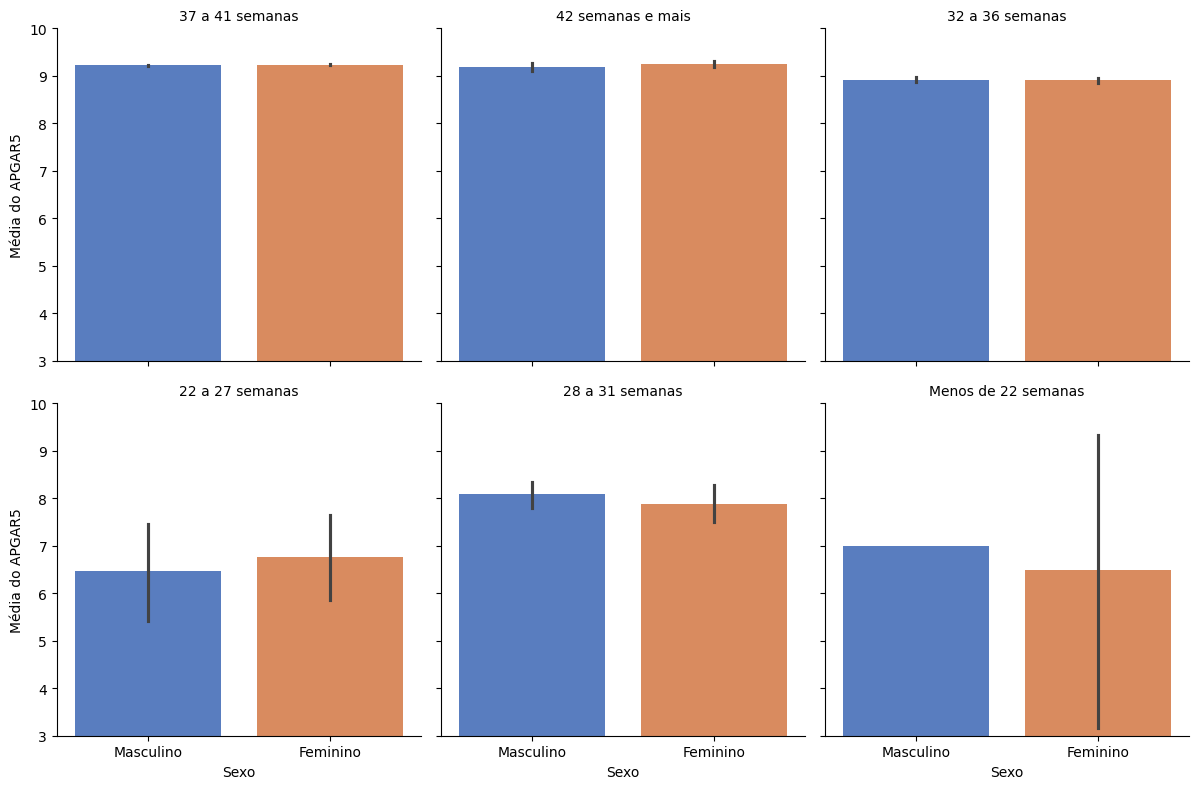

In [20]:

g = sns.catplot(
    data=df_sinasc, 
    x='SEXO', 
    y='APGAR5', 
    hue='SEXO',       
    col='GESTACAO', 
    kind='bar', 
    palette='muted', 
    legend=False,     
    col_wrap=3,
    height=4, 
    aspect=1
)


g.set_axis_labels("Sexo", "Média do APGAR5")
g.set_titles("{col_name}") 
g.tight_layout()

g.set(ylim=(3, 10)) 

plt.show()

####  4) Monte uma tabela cruzada com APGAR5 nas colunas e GESTACAO nas linhas

In [21]:
tabela_apgar_gestacao = pd.crosstab(index=df_sinasc['GESTACAO'], 
                                   columns=df_sinasc['APGAR5'])

tabela_apgar_gestacao

APGAR5,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0
GESTACAO,,,,,,,,,,,
22 a 27 semanas,7,0,8,6,1,0,2,10,24,19,8
28 a 31 semanas,0,0,2,1,5,7,7,11,61,55,13
32 a 36 semanas,2,2,2,2,8,11,17,56,362,1307,465
37 a 41 semanas,5,20,3,5,7,21,45,151,1417,13565,7284
42 semanas e mais,1,0,0,0,0,1,1,5,44,423,223
Menos de 22 semanas,1,0,1,0,0,0,0,1,0,3,1


####  5) Da tabela cruzada do intem anterior, calcule os percentuais de linha. Ou seja, a distribuição da variável APGAR5 para cada classe de GESTACAO dado.

In [22]:

freq_percentual_linha = pd.crosstab(df_sinasc['GESTACAO'], 
                                    df_sinasc['APGAR5'], 
                                    normalize='index') * 100

freq_percentual_linha

APGAR5,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0
GESTACAO,,,,,,,,,,,
22 a 27 semanas,8.235294,0.000000,9.411765,7.058824,1.176471,0.000000,2.352941,11.764706,28.235294,22.352941,9.411765
28 a 31 semanas,0.000000,0.000000,1.234568,0.617284,3.086420,4.320988,4.320988,6.790123,37.654321,33.950617,8.024691
32 a 36 semanas,0.089526,0.089526,0.089526,0.089526,0.358102,0.492390,0.760967,2.506714,16.204118,58.504924,20.814682
37 a 41 semanas,0.022200,0.088798,0.013320,0.022200,0.031079,0.093238,0.199796,0.670426,6.291347,60.227323,32.340274
42 semanas e mais,0.143266,0.000000,0.000000,0.000000,0.000000,0.143266,0.143266,0.716332,6.303725,60.601719,31.948424
Menos de 22 semanas,14.285714,0.000000,14.285714,0.000000,0.000000,0.000000,0.000000,14.285714,0.000000,42.857143,14.285714


####  6) Os médicos costumam classificar parto prematuro quando a gestação tem menos que 37 semanas. Faça um gráfico de barras da tabela cruzada acima e conclua se você acha que este conjunto de dados corrobora ou não com a afirmação dos médicos.

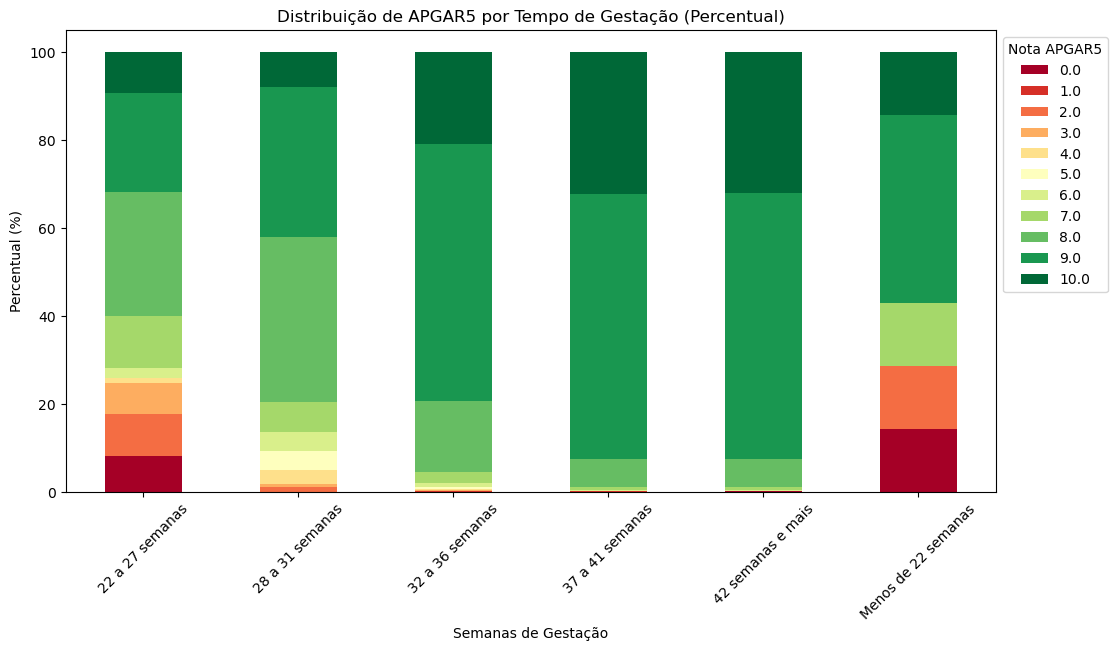

In [12]:
plt.figure(figsize=(12, 6))
freq_percentual_linha.plot(kind='bar', stacked=True, colormap='RdYlGn', ax=plt.gca())

plt.title('Distribuição de APGAR5 por Tempo de Gestação (Percentual)')
plt.ylabel('Percentual (%)')
plt.xlabel('Semanas de Gestação')
plt.legend(title='Nota APGAR5', bbox_to_anchor=(1, 1))
plt.xticks(rotation=45)

plt.show()

#### 7) Veja se há relação entre APGAR5 e o peso do bebê. Isso pode ser feito de diversas formas. Fique à vontade para escolher a melhor maneira na sua opinião, ou até testar mais de um dos gráficos que vimos. Fique à vontade também para consultar a documentação e utilizar algum outro recurso se achar conveniente.

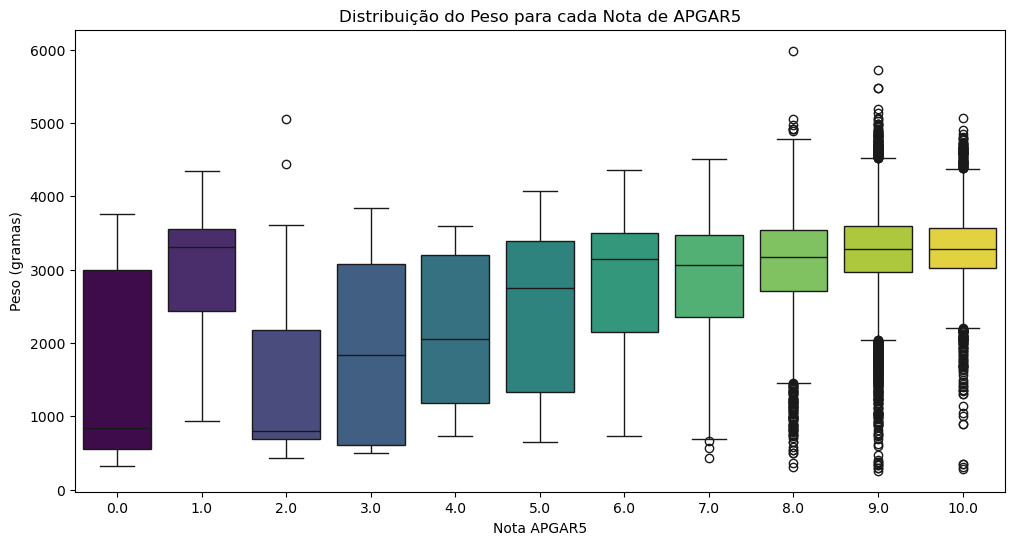

In [19]:
plt.figure(figsize=(12, 6))

# Adicionamos hue='APGAR5' e legend=False para silenciar o aviso
sns.boxplot(x='APGAR5', y='PESO', data=df_sinasc, palette='viridis', hue='APGAR5', legend=False)

plt.title('Distribuição do Peso para cada Nota de APGAR5')
plt.xlabel('Nota APGAR5')
plt.ylabel('Peso (gramas)')
plt.show()

## Existe uma relação clara onde o baixo peso é um fator de risco para um APGAR5 menor. Bebês com peso adequado (entre 3kg e 4kg) têm uma probabilidade muito maior de apresentar vitalidade plena ao nascer.